# 01 - Building the dataset

Monthly oil demand for seven products across seven regions. The OIES paper takes demand from
IEA MODS and its predictors from Oxford Economics, both paid; everything here is a free public
substitute, so the first job is to check the substitutes behave like the originals.

The second job is timing. Macro data describes a period that ended weeks or months before
anyone could read the number. A row dated January 2019 must contain only what had been
published by the end of January 2019, and most of this notebook is about getting that right
rather than approximately right.

Raw files sit in `data/<source>/`, the built tables in `data/oil.duckdb`, the SQL in `sql/`.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from src import config as c, data

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": .3})

data.query("SELECT table_name, estimated_size AS rows FROM duckdb_tables() ORDER BY 1")

,table_name,rows
0,demand,13077
1,panel,2031
2,predictors,28964


## 1. The demand file

JODI-Oil publishes monthly demand by product for around 110 countries. The download is one
650 MB csv holding every flow, unit and product it collects, of which we want one flow
(`TOTDEMO`), one unit (`KBD`, thousand barrels per day, the paper's unit) and seven products.

In [2]:
raw = f"read_csv_auto('{c.JODI_DIR / 'jodi_secondary.csv'}', all_varchar = true)"

duckdb.sql(f"""
    SELECT COUNT(*) AS rows,
           COUNT(DISTINCT FLOW_BREAKDOWN) AS flows,
           COUNT(DISTINCT UNIT_MEASURE) AS units,
           COUNT(DISTINCT ENERGY_PRODUCT) AS products,
           COUNT(DISTINCT REF_AREA) AS countries,
           SUM(CASE WHEN FLOW_BREAKDOWN = 'TOTDEMO' AND UNIT_MEASURE = 'KBD' THEN 1 ELSE 0 END) AS demand_kbd
    FROM {raw}
""").df()

,rows,flows,units,products,countries,demand_kbd
0,15552000,10,5,9,118,311040.0


15.5 million rows, of which the 311,040 demand-in-kbd rows are 2%. Loading the file into pandas
to throw away the other 98% is the wrong move, so `sql/demand.sql` queries it in place.

### Control: which kerosene column is which

JODI reports both `KEROSENE` and `JETKERO`. If they were siblings you would add them; if one
contains the other, adding them double counts jet fuel. Test it against JODI's own total:
the seven products we map should reconstruct `TOTPRODS`.

In [3]:
duckdb.sql(f"""
    WITH wide AS (
        SELECT REF_AREA, TIME_PERIOD,
               MAX(CASE WHEN ENERGY_PRODUCT = 'TOTPRODS' THEN TRY_CAST(OBS_VALUE AS DOUBLE) END) AS total,
               SUM(CASE WHEN ENERGY_PRODUCT IN ('LPG','NAPHTHA','GASOLINE','KEROSENE',
                                                'GASDIES','RESFUEL','ONONSPEC')
                        THEN TRY_CAST(OBS_VALUE AS DOUBLE) END) AS seven,
               MAX(CASE WHEN ENERGY_PRODUCT = 'JETKERO' THEN TRY_CAST(OBS_VALUE AS DOUBLE) END) AS jet
        FROM {raw}
        WHERE FLOW_BREAKDOWN = 'TOTDEMO' AND UNIT_MEASURE = 'KBD'
        GROUP BY 1, 2
        HAVING total > 0 AND seven IS NOT NULL AND jet IS NOT NULL
    )
    SELECT COUNT(*) AS country_months,
           ROUND(MEDIAN(ABS(seven - total) / total) * 100, 3) AS pct_gap_seven,
           ROUND(MEDIAN(ABS(seven + jet - total) / total) * 100, 3) AS pct_gap_with_jet
    FROM wide
""").df()

,country_months,pct_gap_seven,pct_gap_with_jet
0,14413,0.041,5.115


0.04% against 5%: `JETKERO` is the jet subset of `KEROSENE`, and adding it would inflate d4 by
the whole of jet fuel. `config.JODI_PRODUCTS` maps `KEROSENE` alone.

### From countries to the paper's regions

`sql/demand.sql` does the country-to-region join, the product map and the sum in one query. It
also returns how many countries reported, because a regional total is the sum of whoever showed
up that month.

In [4]:
demand = data.query("SELECT * FROM demand ORDER BY region, product, month")
demand["month"] = pd.to_datetime(demand["month"])

print(f"{len(demand):,} region-product-months, {demand.month.min():%Y-%m} to {demand.month.max():%Y-%m}")
print(f"duplicate (region, product, month) keys: {demand.duplicated(['region', 'product', 'month']).sum()}")
print(demand.head(3).to_string(index=False))
print(demand.tail(3).to_string(index=False))

13,077 region-product-months, 2002-01 to 2026-06
duplicate (region, product, month) keys: 0
region product      month       kbd  reporters
  apac  d1_lpg 2002-01-01 1000.3690          4
  apac  d1_lpg 2002-02-01  970.5138          4
  apac  d1_lpg 2002-03-01  903.2403          4
region  product      month       kbd  reporters
    us d7_other 2026-04-01 4297.2000          1
    us d7_other 2026-05-01 4594.4516          1
    us d7_other 2026-06-01 5524.0667          1


### Control: where does each series start, and is any month missing?

The key is unique and `month` is a real timestamp. The other half of the frequency question is
whether the monthly grid has holes: a missing month silently shifts every lag built on top of
it, so it has to be checked before anything is shifted.

In [5]:
months = demand.groupby(["region", "product"])["month"]
cover = pd.DataFrame({"first": months.min(), "last": months.max(), "n": months.size()})
cover["gaps"] = [len(pd.date_range(a, b, freq="MS")) - n
                 for a, b, n in zip(cover["first"], cover["last"], cover["n"])]

print("first month reported")
print(cover["first"].dt.strftime("%Y-%m").unstack().to_string())
print()
print("months missing between first and last")
print(cover["gaps"].unstack().to_string())

first month reported
product          d1_lpg d2_naphtha d3_gasoline d4_jetkero d5_gasoil d6_fueloil d7_other
region                                                                                 
apac            2002-01    2009-01     2002-01    2002-01   2002-01    2002-01  2009-01
china           2004-01    2010-01     2004-01    2004-01   2004-01    2004-01  2009-01
europe          2002-01    2009-01     2002-01    2002-01   2002-01    2002-01  2009-01
india           2002-01    2009-01     2002-01    2002-01   2002-01    2002-01  2009-01
other_americas  2002-01    2009-01     2002-01    2002-01   2002-01    2002-01  2009-01
other_non_oecd  2002-01    2009-01     2002-01    2002-01   2002-01    2002-01  2009-01
us              2002-01    2009-01     2002-01    2002-01   2002-01    2002-01  2009-01

months missing between first and last
product         d1_lpg  d2_naphtha  d3_gasoline  d4_jetkero  d5_gasoil  d6_fueloil  d7_other
region                                                 

No holes anywhere, so the monthly frequency is real rather than assumed. Two series genuinely
start late: JODI collects naphtha and other products only from 2009, and China from 2004. That
is a reporting change at the source, not a gap in our extract, and it comes back below as
leading NaNs rather than as something to fill.

### Control: against the paper's Table 3

The paper prints US 2019 demand by product. Where the product definitions agree, JODI should
land on top of it.

In [6]:
ours = data.query("""
    SELECT product, ROUND(AVG(kbd)) AS kbd
    FROM demand
    WHERE region = 'us' AND YEAR(month) = 2019
    GROUP BY 1
    ORDER BY 1
""").set_index("product").kbd

paper = pd.Series({"d1_lpg": 2638, "d2_naphtha": 207, "d3_gasoline": 9296, "d4_jetkero": 1760,
                   "d5_gasoil": 4112, "d6_fueloil": 306, "d7_other": 2260})
check = pd.DataFrame({"paper (IEA MODS)": paper, "ours (JODI)": ours})
check["diff %"] = (100 * (check["ours (JODI)"] / check["paper (IEA MODS)"] - 1)).round(1)
check

,paper (IEA MODS),ours (JODI),diff %
d1_lpg,2638,1109.0,-58.0
d2_naphtha,207,207.0,0.0
d3_gasoline,9296,9344.0,0.5
d4_jetkero,1760,1764.0,0.2
d5_gasoil,4112,4133.0,0.5
d6_fueloil,306,308.0,0.7
d7_other,2260,3536.0,56.5


Five of seven within 1%. The two that miss are a definition difference rather than an error:
JODI's LPG excludes ethane and the paper's includes it, so roughly 1.5 mb/d sits in our
`d7_other` instead of `d1_lpg`. The pair adds to 4,645 kb/d against the paper's 4,898. The model
is trained and scored on one definition throughout, so this shifts which product carries the
ethane, not the total.

### Control: is the coverage stable?

`v_regional_demand` puts annual demand next to the reporter count. Reading them together is the
check that matters: JODI collects from countries that volunteer, and volunteers leave.

In [7]:
coverage = data.query("SELECT * FROM v_regional_demand WHERE year IN (2010, 2015, 2019, 2023, 2025)")
print("demand, mb/d")
print(coverage.pivot(index="year", columns="region", values="mb_per_day").round(1).to_string())
print()
print("countries reporting")
print(coverage.pivot(index="year", columns="region", values="reporters").astype(int).to_string())

demand, mb/d
region  apac  china  europe  india  other_americas  other_non_oecd    us
year                                                                    
2010     8.0    9.0    13.6    3.1             4.6            20.2  19.4
2015     8.0   10.9    12.8    3.9             4.6            22.1  19.7
2019     7.9   13.7    13.2    4.8             4.7            19.2  20.4
2023     7.5   16.1    12.4    5.1             4.3            13.7  20.4
2025     7.4   16.6    12.4    5.5             4.4            12.1  20.7

countries reporting
region  apac  china  europe  india  other_americas  other_non_oecd  us
year                                                                  
2010       4      1      19      1               3              59   1
2015       4      1      19      1               3              63   1
2019       4      1      19      1               3              45   1
2023       4      1      19      1               3              39   1
2025       4      1      19  

The six named regions are stable - the US holds 20 mb/d, China grows, Europe drifts down as it
should. Other non-OECD collapses from 22 mb/d to 12 while its reporter count falls, which is
members leaving JODI rather than a continent halving its oil use.

Two consequences carried forward:

- the six named regions are fit for a level forecast; **other non-OECD is not**, and its numbers
  are a data artefact rather than a demand view;
- the 2019 test window sits before most of the erosion, so the US and China comparisons with the
  paper are unaffected.

One more read on the same table, as a shape check: the product mix should look like the
economies it comes from.

In [8]:
mix = data.query("""
    SELECT region, product, ROUND(pct, 1) AS pct
    FROM v_product_mix
    WHERE year = 2019
""")
mix.pivot(index="region", columns="product", values="pct")

product,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other
region,,,,,,,
apac,9.4,24.9,18.3,11.3,23.5,5.3,7.4
china,13.8,6.5,21.3,6.0,21.2,3.8,27.3
europe,7.5,6.8,14.2,10.6,44.6,5.3,10.9
india,17.5,6.9,14.5,5.0,36.0,2.3,17.8
other_americas,12.0,1.0,33.6,6.1,24.0,4.4,18.8
other_non_oecd,12.4,3.5,26.4,6.6,32.6,10.3,8.3
us,5.4,1.0,45.8,8.6,20.3,1.5,17.3


Gasoline is 46% of US barrels and 14% of Europe's, where gasoil is 45%; China puts 27% into
other products, which is the ethane and petrochemical feedstock line. That is the right shape,
and a mapping error would not produce it.

## 2. Timestamps: reference period is not availability

Every predictor arrives on its own calendar. Before using any of them, look at what each one is:
how often it prints, how far back it goes, and how long after the period it describes it becomes
readable.

In [9]:
pred = data.query("SELECT * FROM predictors WHERE region = 'us' ORDER BY variable, period_end")
pred["spacing"] = pred.groupby("variable")["period_end"].diff().dt.days
pred["lag"] = (pred["available_at"] - pred["period_end"]).dt.days

frequency = pred.groupby("variable").agg(obs=("value", "size"),
                                         first=("period_end", "min"), last=("period_end", "max"),
                                         spacing_days=("spacing", "median"),
                                         publication_lag_days=("lag", "median"))
frequency["first"] = frequency["first"].dt.strftime("%Y-%m")
frequency["last"] = frequency["last"].dt.strftime("%Y-%m")
print(frequency.to_string())
print()
print("published on or after the period described:", (pred.available_at >= pred.period_end).all())

           obs    first     last  spacing_days  publication_lag_days
variable                                                            
airf       450  1989-01  2026-07          31.0                  61.0
airp        34  1990-12  2023-12         365.0                 365.0
cbui       402  1993-01  2026-06          31.0                  30.0
chem       655  1972-01  2026-07          31.0                  30.0
cons       106  2000-03  2026-06          91.0                  61.0
cpi        954  1947-01  2026-07          31.0                  30.0
egen        35  1990-12  2024-12         365.0                 365.0
gdp        318  1947-03  2026-06          91.0                  30.0
inc        810  1959-01  2026-06          31.0                  30.0
ind       1291  1919-01  2026-07          31.0                  30.0
inv        318  1947-03  2026-06          91.0                  30.0
pcars      607  1976-01  2026-07          31.0                  30.0
pop        810  1959-01  2026-06  

Three frequencies in one table: 30-31 days between observations is monthly, 91 is quarterly, 365
is annual. The publication lag is what makes them usable together - a Brent monthly average is
known the day the month ends, US GDP about a month after the quarter closes, the World Bank file
a year after the year. Those gaps are `config.LAG`, publication conventions rather than guesses,
and `available_at = period_end + LAG` is the only date the modelling is allowed to look at.

In [10]:
print(c.LAG)
data.query("SELECT * FROM v_publication_lag").head(12)

{'demand': 2, 'price': 0, 'fred_monthly': 1, 'fred_quarterly': 1, 'aviation': 2, 'oecd': 2, 'worldbank': 12, 'trade': 2}


,variable,source,observations,lag_months
0,airp,worldbank,238,12.0
1,egen,worldbank,208,12.0
2,gdp,worldbank,72,12.0
3,inv,worldbank,70,12.0
4,pop,worldbank,216,12.0
5,airf,fred,3150,2.0
6,cbui,oecd,1248,2.0
7,cons,oecd,529,2.0
8,cpi,oecd,1560,2.0
9,gdp,oecd,423,2.0


### Aligning with `merge_asof`

The panel is monthly. Predictors arrive on their own calendars - monthly, quarterly, annual -
each on its own publication schedule. That is exactly the asynchronous case
`merge_asof(direction="backward")` is for: as of the end of month t, take the most recent
observation whose `available_at` is on or before t.

A `tolerance` of two years goes with it. A series that has not printed in two years has not
merely slipped, it has stopped, and carrying its last value forward forever would be a silent
fiction. Past the tolerance the value goes missing, which XGBoost handles.

In [11]:
releases = data.query("""
    SELECT period_end, available_at, ROUND(value, 1) AS value
    FROM predictors
    WHERE region = 'us' AND variable = 'gdp'
      AND available_at BETWEEN DATE '2018-09-01' AND DATE '2019-05-31'
    ORDER BY available_at
""")
print("US GDP releases either side of the 2019 forecast origin:")
print(releases.to_string(index=False))

panel = data.load_panel()
us = data.region_frame("us")
print()
print("what the panel carries:")
print(us.loc["2018-10":"2019-04", ["gdp", "cpi", "ind", "rpo"]].to_string())

US GDP releases either side of the 2019 forecast origin:
period_end available_at   value
2018-09-30   2018-10-30 20798.7
2018-12-31   2019-01-31 20917.9
2019-03-31   2019-04-30 21111.6

what the panel carries:
                  gdp      cpi       ind        rpo
2018-10-01  20798.730  252.182  104.1004  80.783478
2018-11-01  20798.730  252.772  103.9856  66.228636
2018-12-01  20798.730  252.594  104.0681  57.948095
2019-01-01  20917.867  252.767  104.0936  59.944783
2019-02-01  20917.867  252.561  103.4021  64.384000
2019-03-01  20917.867  253.319  102.8371  66.941905
2019-04-01  21111.600  254.277  102.8757  71.475909


December 2018 carries Q3 GDP, because Q4 did not exist yet. January 2019 steps to Q4. That is
the whole point.

### What interpolating would have done

The paper converts quarterly predictors to monthly with `interpolate(method="linear")`. It is
smooth and convenient, and it reads the *next* quarter's number to fill the months in between.
Through a turning point the difference is not cosmetic.

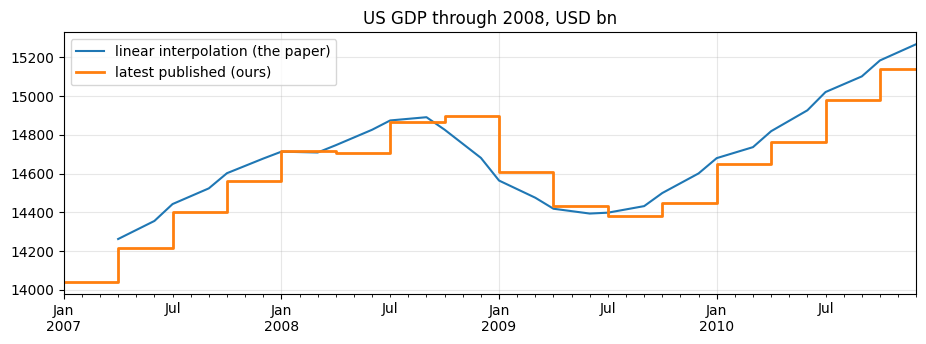

In [12]:
quarterly = data.query("""
    SELECT period_end, value FROM predictors
    WHERE region = 'us' AND variable = 'gdp'
      AND period_end BETWEEN DATE '2007-01-01' AND DATE '2010-12-31'
    ORDER BY period_end
""").set_index("period_end").value
interpolated = quarterly.resample("MS").interpolate("linear")

fig, ax = plt.subplots()
interpolated.plot(ax=ax, label="linear interpolation (the paper)")
us.gdp.loc["2007":"2010"].plot(ax=ax, drawstyle="steps-post", lw=2, label="latest published (ours)")
ax.set_title("US GDP through 2008, USD bn"); ax.set_xlabel(""); ax.legend();

The interpolated line starts falling months before the fall was reported. A model trained on it
learns to see recessions early and cannot repeat the trick out of sample.

## 3. Missing values

Start with the count, then with where they sit - the two answers are different questions.

In [13]:
panel.isna().sum()

region            0
month             0
d1_lpg            0
d2_naphtha      576
d3_gasoline       0
d4_jetkero        0
d5_gasoil         0
d6_fueloil        0
d7_other        564
airf              0
airp              0
cbui            585
chem           1737
cons            564
cpi             294
egen            294
gdp               0
inc             855
ind             564
inv               0
out            1149
pcars           587
pop               0
ppi            1737
rpk               0
rpo               0
wci               0
wtr               0
dtype: int64

In [14]:
(panel.set_index(["region", "month"]).isna().groupby("region").mean() * 100).round(0).astype(int).T

region,apac,china,europe,india,other_americas,other_non_oecd,us
d1_lpg,0,0,0,0,0,0,0
d2_naphtha,29,27,29,29,29,29,29
d3_gasoline,0,0,0,0,0,0,0
d4_jetkero,0,0,0,0,0,0,0
d5_gasoil,0,0,0,0,0,0,0
d6_fueloil,0,0,0,0,0,0,0
d7_other,29,22,29,29,29,29,29
airf,0,0,0,0,0,0,0
airp,0,0,0,0,0,0,0
cbui,0,0,0,100,0,100,0


- **Whole columns missing for a region.** China has no free monthly production index and no OECD
  quarterly accounts; `chem` and `ppi` are US-only. These stay missing. XGBoost sends missing
  values down a learned default branch, which is one of the reasons the paper chose it, and
  inventing a number for China's industrial production would be worse than admitting we do not
  have one.
- **A leading gap.** The coverage table above: naphtha and other products only exist from 2009,
  so those two columns are empty for the first seven years. The paper backcasts them with
  Prophet. We do not - fabricating seven years of history from a trend fitted to the later data
  is a large liability for two products, and the model trains on the sample that exists.

## 4. Transformation: is the target stationary, and does it need to be?

The paper's data processing chapter differences its series before modelling. Differencing is a
requirement for a model that assumes a stable mean - and it also changes what is being
forecast, from a level in kb/d to a change in kb/d. So it is worth looking at the series before
deciding rather than transforming out of habit.

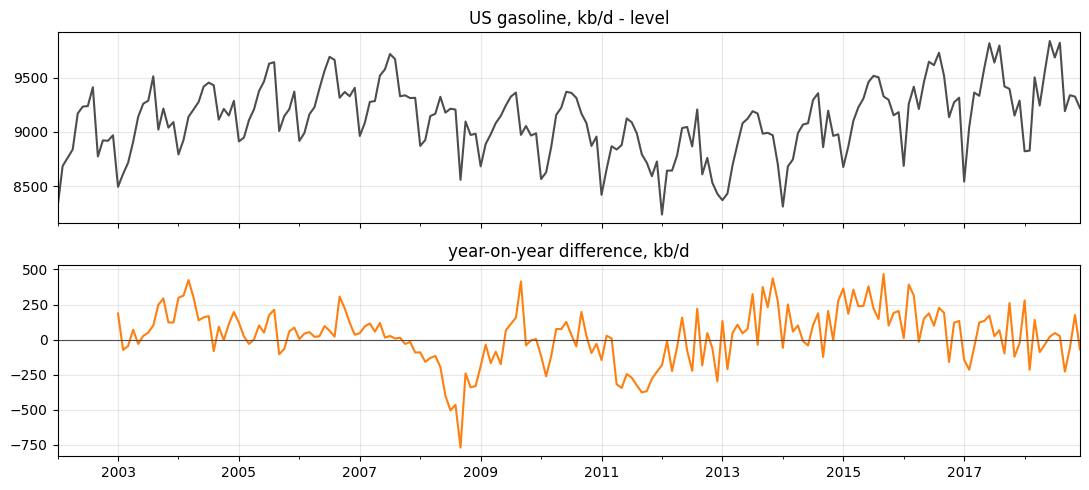

In [15]:
gasoline = us["d3_gasoline"]

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
gasoline.loc[:"2018"].plot(ax=axes[0], color="0.3", title="US gasoline, kb/d - level")
gasoline.diff(12).loc[:"2018"].plot(ax=axes[1], color="C1", title="year-on-year difference, kb/d")
axes[1].axhline(0, color="0.3", lw=.8)
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout();

In [16]:
# rolling moments of the same series, level against seasonal difference
pd.DataFrame({"mean, level": gasoline.rolling(24).mean(), "std, level": gasoline.rolling(24).std(),
              "mean, diff12": gasoline.diff(12).rolling(24).mean(),
              "std, diff12": gasoline.diff(12).rolling(24).std()}).loc["2005":"2018":36].round(0)

,"mean, level","std, level","mean, diff12","std, diff12"
2005-01-01,9131.0,233.0,130.0,133.0
2008-01-01,9350.0,231.0,53.0,87.0
2011-01-01,9042.0,254.0,-2.0,145.0
2014-01-01,8811.0,275.0,43.0,200.0
2017-01-01,9282.0,284.0,176.0,153.0


The level wanders - the 24-month mean moves 500 kb/d between 2008 and 2014 - while the
year-on-year difference sits around zero throughout. That is the informal stationarity read:
mean not constant in levels, roughly constant once differenced.

The formal version, on the training sample only so the 2019 test year plays no part in the
decision: autocorrelation at lag 1 and at lag 12, for the level, the first difference and the
seasonal difference.

In [17]:
history = us.loc[:c.TRAIN_END, c.PRODUCTS]
acf = lambda s, k: s.dropna().autocorr(k)

pd.DataFrame({"level, acf1":  [acf(history[p], 1) for p in c.PRODUCTS],
              "level, acf12": [acf(history[p], 12) for p in c.PRODUCTS],
              "diff1, acf1":  [acf(history[p].diff(), 1) for p in c.PRODUCTS],
              "diff1, acf12": [acf(history[p].diff(), 12) for p in c.PRODUCTS],
              "diff12, acf1": [acf(history[p].diff(12), 1) for p in c.PRODUCTS],
              "diff12, acf12": [acf(history[p].diff(12), 12) for p in c.PRODUCTS]},
             index=c.PRODUCTS).round(2)

,"level, acf1","level, acf12","diff1, acf1","diff1, acf12","diff12, acf1","diff12, acf12"
d1_lpg,0.83,0.85,0.21,0.56,0.50,-0.38
d2_naphtha,0.52,0.17,-0.36,0.11,0.50,-0.39
d3_gasoline,0.72,0.82,-0.24,0.71,0.56,-0.00
d4_jetkero,0.86,0.82,-0.40,0.47,0.61,0.10
d5_gasoil,0.67,0.55,-0.39,0.37,0.55,-0.02
d6_fueloil,0.92,0.86,-0.40,0.07,0.48,-0.29
d7_other,0.81,0.61,-0.31,0.16,0.46,-0.34


Reading the three blocks:

- **Level.** acf1 between 0.5 and 0.9, and acf12 above 0.55 for every product except naphtha -
  persistent and strongly seasonal. Not stationary.
- **First difference.** acf1 turns negative or near zero, so the persistence is gone, but acf12
  stays at 0.71 for gasoline and 0.47 for jet/kero: a first difference does not touch the
  seasonality.
- **Seasonal difference.** acf12 collapses to about zero for gasoline, gasoil and jet/kero. The
  seasonal difference is the one that matters for these series, which says the dominant structure
  is the calendar, not a trend.

The model keeps the target in levels anyway, for three reasons that are worth being able to
defend:

1. the deliverable is a level in kb/d and MAPE is computed on levels, so a differenced model
   would have to be integrated back before scoring, re-importing the level uncertainty;
2. the features are the twelve monthly lags d(t-2) ... d(t-13), so `lag12` and `lag13` hold the
   same calendar month as the target. A tree can build a "last year's value plus an adjustment"
   rule from them, which is the seasonal difference expressed as a split rather than imposed as a
   transform;
3. the forecast is direct - one model per horizon - so errors are not integrated forward the way
   they are in a recursive differenced model.

The price of that choice is real and specific: **a tree cannot predict outside the range of the
target it was trained on**. If 2019 demand leaves the training range, a level model is capped by
construction. That is measurable rather than a matter of opinion.

In [18]:
for name in ["us", "china"]:
    df = data.region_frame(name)[c.PRODUCTS]
    train, test = df.loc[:c.TRAIN_END], df.loc["2019"]
    print(name)
    print(pd.DataFrame({"train min": train.min(), "train max": train.max(),
                        "2019 min": test.min(), "2019 max": test.max(),
                        "months outside": [(test[p].lt(train[p].min()) | test[p].gt(train[p].max())).sum()
                                           for p in c.PRODUCTS]}).round(0).to_string(), end="\n\n")

us
             train min  train max  2019 min  2019 max  months outside
d1_lpg           686.0     1884.0     778.0    1585.0               0
d2_naphtha       181.0      304.0     139.0     240.0               1
d3_gasoline     8239.0     9839.0    8809.0    9872.0               1
d4_jetkero      1335.0     1881.0    1637.0    1863.0               0
d5_gasoil       3450.0     4651.0    3942.0    4353.0               0
d6_fueloil       205.0     1157.0     208.0     378.0               0
d7_other        2536.0     4095.0    3294.0    3798.0               0

china
             train min  train max  2019 min  2019 max  months outside
d1_lpg           469.0     2019.0    1780.0    2013.0               0
d2_naphtha       522.0     1005.0     840.0     974.0               0
d3_gasoline      938.0     3114.0    2709.0    3328.0               3
d4_jetkero       117.0      851.0     697.0     959.0               5
d5_gasoil       1561.0     4029.0    2639.0    3198.0               0
d6_fueloil

The US is fine: one month of naphtha below the training minimum, one month of gasoline above the
maximum, so the 2019 forecast is an interpolation of things the model has seen. China is not -
gasoline is above its training maximum in 3 months of 2019, jet/kero in 5, other products in 2,
because Chinese demand is still growing through the sample. In those months a level model is
capped by construction and can only under-forecast. That is the cost of the choice, stated
plainly: modelling the year-on-year difference and integrating back is the honest fix for a
trending region, and it is the first thing to try if this were pushed past 2019 or past China.

## 5. Transformation: does anything need scaling?

The paper scales its features. The drivers here span six orders of magnitude - Brent in dollars,
population in thousands, air traffic in passenger-kilometres - so the question is fair.

In [19]:
drivers = ["rpo", "cpi", "ind", "gdp", "pop", "rpk"]
train = us.loc[:c.TRAIN_END, drivers]

print("raw, training sample")
print(train.agg(["mean", "std", "min", "max"]).T.round(1).to_string())
print()
print("standardised on the training sample only")
print(((us[drivers] - train.mean()) / train.std()).loc[:c.TRAIN_END]
      .agg(["mean", "std", "min", "max"]).T.round(2).to_string())

raw, training sample
           mean         std         min         max
rpo        69.4        29.4        20.0       133.6
cpi       217.4        21.6       177.4       252.8
ind        96.7         4.8        84.7       104.1
gdp     15375.0      2748.7     10660.5     20798.7
pop    308969.1     12732.1    286533.0    329527.0
rpk  69038196.2  10372566.2  45157584.0  99373488.0

standardised on the training sample only
     mean  std   min   max
rpo   0.0  1.0 -1.68  2.18
cpi  -0.0  1.0 -1.85  1.64
ind   0.0  1.0 -2.52  1.54
gdp   0.0  1.0 -1.72  1.97
pop   0.0  1.0 -1.76  1.61
rpk  -0.0  1.0 -2.30  2.92


Standardising works - every column comes back on mean 0 and standard deviation 1 - and it buys
nothing here. XGBoost splits on `feature <= threshold`; any strictly increasing rescaling maps
the same rows to the same side of every candidate split, so the fitted trees are identical and
only the printed thresholds change. Keeping the raw units means a split reads as "Brent above
$70" rather than "z above 0.02".

Two things this would change if the model changed:

- a ridge, a k-nearest-neighbour or a neural net compares features on a common metric and would
  be dominated by `rpk` at 1e8 unless scaled. Then scaling is not optional;
- the scaler itself is a fitted object. Note `train.mean()` and `train.std()` above are taken on the
  training sample only. Standardising on the full sample would push the 2019 mean into the
  training features - a small leak, but the same kind of leak as everything else this notebook
  is guarding against.

## 6. Sanity checks


In [20]:
for region, part in panel.groupby("region"):
    assert part.month.is_unique and part.month.is_monotonic_increasing, region
    assert len(part) == len(pd.date_range(part.month.min(), part.month.max(), freq="MS")), region

nonpositive = data.query("SELECT region, product, month, kbd FROM demand WHERE kbd <= 0")
world = panel.groupby("month")[c.PRODUCTS].sum().sum(axis=1) / 1000

print(f"regions               {panel.region.nunique()}, months contiguous and unique")
print(f"months per region     {sorted(panel.groupby('region').size().unique())}")
print(f"non-positive demand   {len(nonpositive)} rows")
print(nonpositive.to_string(index=False))
print()
print(f"world demand 2019     {world.loc['2019'].mean():.1f} mb/d   (IEA reported 100.1)")
print(f"world demand 2023     {world.loc['2023'].mean():.1f} mb/d   (IEA reported 101.7)")

regions               7, months contiguous and unique
months per region     [np.int64(270), np.int64(291), np.int64(294)]
non-positive demand   1 rows
region    product      month  kbd
    us d2_naphtha 2026-06-01  0.0

world demand 2019     83.9 mb/d   (IEA reported 100.1)
world demand 2023     79.4 mb/d   (IEA reported 101.7)


In [21]:
# largest month-on-month moves in US demand: real volatility or a reporting accident?
moves = us[c.PRODUCTS].pct_change().mul(100).stack().rename("pct change")
moves.loc[moves.abs().nlargest(5).index].round(1)

2020-06-01  d6_fueloil    135.9
2026-06-01  d2_naphtha   -100.0
2016-03-01  d6_fueloil     86.7
2021-05-01  d6_fueloil     80.9
2014-01-01  d6_fueloil     78.2
Name: pct change, dtype: float64

One zero, US naphtha in the most recent month, which is late reporting rather than a real
observation. It sits seven years past the test window so it never reaches the model, but a zero
is worth naming: MAPE divides by the actual, so a zero in a scored month would blow the metric up
rather than merely degrade it.

The five largest monthly moves are that same zero again, plus four in fuel oil. US fuel oil runs
at 200-400 kb/d inside a 20,000 kb/d barrel, so a 200 kb/d swing in utility and bunker burn is an
80% move on the product and 1% of national demand; June 2020 and May 2021 are COVID. None of them
is a decimal-point error, and none falls in the 2019 test window.

84 mb/d against the IEA's 100.1 is JODI's coverage, consistent with the reporter table above.

---

`panel` in `data/oil.duckdb` is the modelling table: one row per region-month, seven demand
columns and nineteen drivers, every driver as of information available that month. Notebook 02
turns it into a supervised learning problem.